# Классификация экзопланет по кривым блеска (Kaggle: ExoPlanet)

Бинарная классификация звёзд по данным фотометрии: необходимо реализовать модель, способную определить, есть ли у звезды подтверждённая экзопланета

## Данные
- `exoTrain.csv` — 5087 объектов, `exoTest.csv` — 570.
- Признаки: `LABEL` (1 — нет планеты, 2 — есть) и 3197 значений `FLUX.*` — временной ряд кривой блеска.

# Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import skew, kurtosis
from scipy.fft import rfft
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# Чтение и общий вид

In [2]:
train = pd.read_csv("../data/exoTrain.csv")
test = pd.read_csv("../data/exoTest.csv")

In [3]:
train.head(10)

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54
5,2,211.10,163.57,179.16,187.82,188.46,168.13,203.46,178.65,166.49,...,-98.45,30.34,30.34,29.62,28.80,19.27,-43.90,-41.63,-52.90,-16.16
6,2,9.34,49.96,33.30,9.63,37.64,20.85,4.54,22.42,10.11,...,-58.56,9.93,9.93,23.50,5.28,-0.44,10.90,-11.77,-9.25,-36.69
7,2,238.77,262.16,277.80,190.16,180.98,123.27,103.95,50.70,59.91,...,-72.48,31.77,31.77,53.48,27.88,95.30,48.86,-10.62,-112.02,-229.92
8,2,-103.54,-118.97,-108.93,-72.25,-61.46,-50.16,-20.61,-12.44,1.48,...,43.92,7.24,7.24,-7.45,-18.82,4.53,21.95,26.94,34.08,44.65
9,2,-265.91,-318.59,-335.66,-450.47,-453.09,-561.47,-606.03,-712.72,-685.97,...,3671.03,2249.28,2249.28,2437.78,2584.22,3162.53,3398.28,3648.34,3671.97,3781.91


In [4]:
train.describe()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.007273,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,0.084982,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,1.000000,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,1.000000,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,1.000000,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,1.000000,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,2.000000,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


In [5]:
train.shape

(5087, 3198)

In [6]:
train.dtypes

LABEL          int64
FLUX.1       float64
FLUX.2       float64
FLUX.3       float64
FLUX.4       float64
              ...   
FLUX.3193    float64
FLUX.3194    float64
FLUX.3195    float64
FLUX.3196    float64
FLUX.3197    float64
Length: 3198, dtype: object

# *Сильный дисбаланс классов*

37 vs 5050

In [7]:
print(train["LABEL"].value_counts())

LABEL
1    5050
2      37
Name: count, dtype: int64


# Визуализированный пример

Сравнение данных звезды с планетой/без планеты для понимания

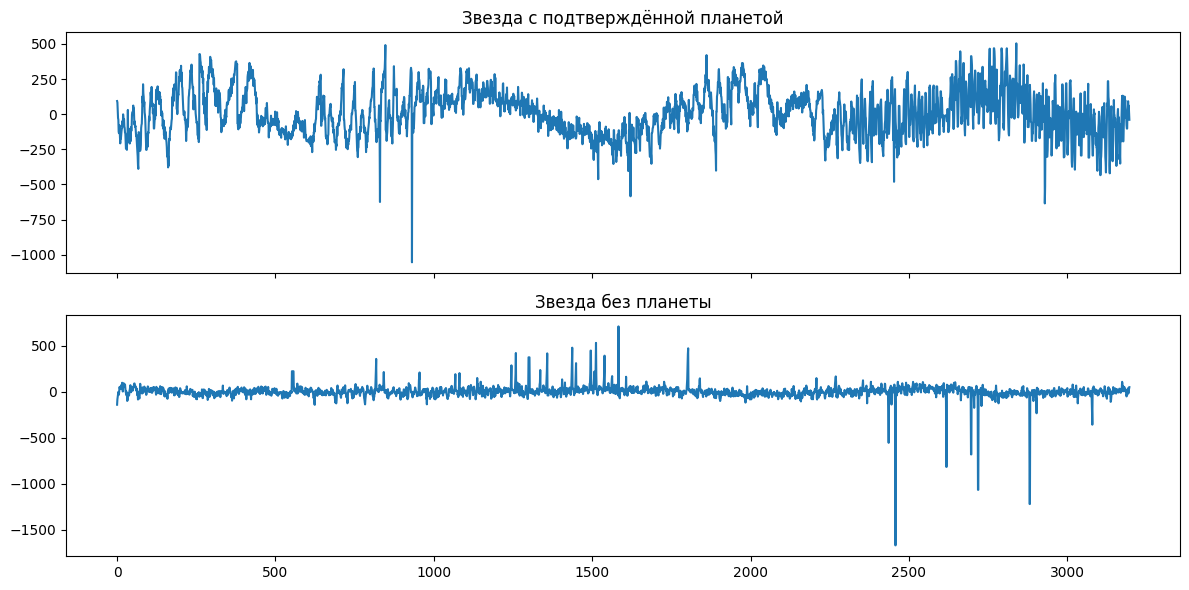

In [8]:
flux_cols = [c for c in train.columns if c.startswith("FLUX")]

planet_example = train[train["LABEL"] == 2].iloc[0][flux_cols].values
no_planet_example = train[train["LABEL"] == 1].iloc[0][flux_cols].values

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(planet_example)
axes[0].set_title("Звезда с подтверждённой планетой")
axes[1].plot(no_planet_example)
axes[1].set_title("Звезда без планеты")
plt.tight_layout()
plt.show()

*Видно, что данные звезды без планеты ведут себя в среднем намного спокойнее, не считая выбросов (вспышек, вероятно), в то время как данные со звезды с подтверждённой планетой двигаются с куда большей амплитудой*

# Построчная нормализация

Т. к. данные даны в виде временных рядов, где звёзды - это строки, и масштабировать разные излучения с разных звёзд в один и тот же момент времени неэффективно, т. к. у каждой звезды своя норма излучения, и одна может попросту перекрывать другую, имеет смысл сделать масштабирование по каждой звезде по отдельности - т. е. провести построчную нормализацию

In [9]:
def normalize_rows(df, flux_cols):
    values = df[flux_cols].values
    medians = np.median(values, axis=1, keepdims=True)
    mads = np.median(np.abs(values - medians), axis=1, keepdims=True)
    mads[mads == 0] = 1  # защита от деления на ноль
    return (values - medians) / mads

In [10]:
X_train = normalize_rows(train, flux_cols)
X_test = normalize_rows(test, flux_cols)

y_train = (train["LABEL"] == 2).astype(int)
y_test = (test["LABEL"] == 2).astype(int)

# Baseline-модель со взвешиванием весов (проверим эффективность нескольких моделей и сверим их результаты между собой)

# Случайный лес

In [11]:
rand_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=52
)
rand_forest.fit(X_train, y_train)

y_pred = rand_forest.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[565   0]
 [  5   0]]
              precision    recall  f1-score   support

           0      0.991     1.000     0.996       565
           1      0.000     0.000     0.000         5

    accuracy                          0.991       570
   macro avg      0.496     0.500     0.498       570
weighted avg      0.983     0.991     0.987       570



c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

# Логрегрессия

In [12]:
log_regression = LogisticRegression(
    class_weight="balanced",
    random_state=52
)
log_regression.fit(X_train, y_train)

y_pred = log_regression.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[455 110]
 [  3   2]]
              precision    recall  f1-score   support

           0      0.993     0.805     0.890       565
           1      0.018     0.400     0.034         5

    accuracy                          0.802       570
   macro avg      0.506     0.603     0.462       570
weighted avg      0.985     0.802     0.882       570



c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Градиентный бустинг

In [13]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=52
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[565   0]
 [  5   0]]
              precision    recall  f1-score   support

           0      0.991     1.000     0.996       565
           1      0.000     0.000     0.000         5

    accuracy                          0.991       570
   macro avg      0.496     0.500     0.498       570
weighted avg      0.983     0.991     0.987       570



c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

Из всех трёх моделей хоть какой-то результат показала только логрегрессия (2 угаданные планеты из 5). Остальные не угадали ни одной, просто выбирая во всех случаях доминирующий класс (несмотря на сбалансированные веса классов). Возможно, моделям просто тяжело обнаружить какие-то закономерности в таком огромном (3197) кол-ве столбов. С учётом такого маленького кол-ва положительных примеров, это вполне возможно

*Можно попробоватьуменьшить кол-во фич, преобразовав изначальный набор временных рядов в какой-то более понятный моделям набор параметров*

In [14]:
def extract_features(X):
    feats = pd.DataFrame({
        "mean": X.mean(axis=1),
        "std": X.std(axis=1),
        "skew": skew(X, axis=1),          # асимметрия — транзиты дают резкую асимметрию (провалы, а не всплески)
        "kurtosis": kurtosis(X, axis=1),  # эксцесс — насколько "острые" выбросы в сигнале
        "min": X.min(axis=1),
        "ptp": X.max(axis=1) - X.min(axis=1),  # размах (peak-to-peak)
    })
    # Спектральные признаки: периодичность сигнала видна в частотной области,
    # даже если сам провал сдвинут по времени между звёздами
    fft_vals = np.abs(rfft(X, axis=1))
    feats["fft_max"] = fft_vals.max(axis=1)
    feats["fft_mean"] = fft_vals.mean(axis=1)
    return feats

In [15]:
train_feats = extract_features(X_train)
test_feats = extract_features(X_test)

In [16]:
train_feats.head()

,mean,std,skew,kurtosis,min,ptp,fft_max,fft_mean
0,0.089854,1.449214,0.004392,0.408338,-9.504554,14.053837,1810.366154,47.825084
1,-0.317725,2.563077,-2.273858,10.046725,-15.859889,26.651431,1193.552636,89.866735
2,0.058180,1.982920,0.358542,2.200535,-6.155421,15.123760,2575.104600,46.166451
3,-0.063593,1.415753,-0.004433,-0.029248,-3.681251,8.760115,2360.120799,22.814210
4,-0.048119,1.373524,-0.527380,0.144301,-6.103320,9.222162,1370.668468,28.760922


# Проверяем те же модели на новом датасете

In [17]:
rand_forest_new = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=52
)
rand_forest_new.fit(train_feats, y_train)

y_pred = rand_forest_new.predict(test_feats)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[565   0]
 [  5   0]]
              precision    recall  f1-score   support

           0      0.991     1.000     0.996       565
           1      0.000     0.000     0.000         5

    accuracy                          0.991       570
   macro avg      0.496     0.500     0.498       570
weighted avg      0.983     0.991     0.987       570



c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [18]:
log_regression_new = LogisticRegression(
    class_weight="balanced",
    random_state=52
)
log_regression_new.fit(train_feats, y_train)

y_pred = log_regression_new.predict(test_feats)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[471  94]
 [  1   4]]
              precision    recall  f1-score   support

           0      0.998     0.834     0.908       565
           1      0.041     0.800     0.078         5

    accuracy                          0.833       570
   macro avg      0.519     0.817     0.493       570
weighted avg      0.989     0.833     0.901       570



c:\Users\Vladislav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
xgb_model_new = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=52
)

xgb_model_new.fit(train_feats, y_train)

y_pred = xgb_model_new.predict(test_feats)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[562   3]
 [  4   1]]
              precision    recall  f1-score   support

           0      0.993     0.995     0.994       565
           1      0.250     0.200     0.222         5

    accuracy                          0.988       570
   macro avg      0.621     0.597     0.608       570
weighted avg      0.986     0.988     0.987       570



# Логрегрессия показывает хорошие результаты (recall планет 80%), но остальные модели - вновь ничего

**(xgb угадал 1 раз, но это скорее случайность, т. к. на многих других сидах он не находит нисчего)**

Для проверки успеха логрегрессии и исключения ошибки с другими моделями следует провести кросс-валидацию

# Кросс-валидация

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_regression_valid = LogisticRegression(class_weight="balanced", max_iter=1000)

scores = cross_val_score(log_regression_valid, train_feats, y_train, cv=cv, scoring="recall")
print(scores, scores.mean())

[0.625      0.75       0.71428571 0.85714286 0.57142857] 0.7035714285714286


In [21]:
rand_forest_valid = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=52
)

scores = cross_val_score(rand_forest_valid, train_feats, y_train, cv=cv, scoring="recall")
print(scores, scores.mean())

[0. 0. 0. 0. 0.] 0.0


In [22]:
xgb_model_valid = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=52
)

scores = cross_val_score(xgb_model_valid, train_feats, y_train, cv=cv, scoring="recall")
print(scores, scores.mean())

[0. 0. 0. 0. 0.] 0.0


# Валидаия подтвердила и успех логрегрессии, и абсолютные неудачи случайного леса и градиентного бустинга

Новая гипотеза: возможно, RF и RGB не работают в связи с тем, что они **используют разбиения датасета, а не сам изначальный датасет**, что в связке с тем, что у нас **мало хороших примеров**, может привести к тому, что, например, в RF у многих деревьев положительных примеров может **вовсе не быть**, или же они просто **подстраиваются под шум случайных 1-2 примеров**

Проверим гипотезу, проведя валидацию на сбалансированном на уровне *bootstrap* случайном лесе

In [23]:
balanced_rf = BalancedRandomForestClassifier(
    n_estimators=300,
    random_state=52
)
scores = cross_val_score(balanced_rf, train_feats, y_train, cv=cv, scoring="recall")
print(scores, scores.mean())

[0.5        0.25       0.71428571 0.85714286 0.14285714] 0.4928571428571429


В целом, стало лучше: в отличие от полностью нулевого результата обычного RF со сбалансированными весами и от XGB с 1 единственным случайным попаданием, тут присутствует хоть какой-то средний отличный от нуля recall - **примерно 50% положительных примеров угадывается**, что, несомненно, движение в правльном направлении, но, с учётом среднего *recall около 70% у обыной логрегрессии со сбалансированными весам* стоит задуматься об отбрасывании моделей, основанных на алгоритмах разбиения изначального датасета, т. к. они могут попросто неэффективны именно для этой задачи и этого набора данных, и **направить все усилия на улучшение логрегрессии или нахождение подобного удачного алгоритма**

Как итог:
- были испробованы три модели (LR, RF, XGB) и протестированы при помощи **5-fold кросс-валидации**;
- наибольший успех показала модель логрегрессии: средний recall положительных примеров 70%;
- сбалансированный случайный лес показал recall 49%;
- XGB оказался неэффесктивен, как и обычный RF